In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import Obs, ObsVecNoise, Univariate, WSAInputData, WSAHUX215Model

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

In [14]:
data = WSAInputData.load("../data/nso_gong_CR2047.json")

# Set up model priors
model = WSAHUX215Model([
    # min speed
    Univariate.uniform("a1", 250, 400),
    # max speed
    Univariate.uniform("a2", 500, 620),
    # expansion factor coefficient
    Univariate.uniform("a3", 2.1 / 9, 2.5 / 9),
    # exp offset
    Univariate.uniform("a4", 0.75, 0.95),
    # expansion factor
    Univariate.uniform("a5", 0.55, 0.7),
    # distance fraction (DON'T CHANGE)
    Univariate.constant("a6", 2),
    # distance factor coefficient
    Univariate.uniform("a7", 1.8, 2.2),
    # coefficient everything
    Univariate.constant("a8", 3),
],
data,
2.0
)

ref_data = np.array([
        368.0, 366.0, 376.0, 373.0, 375.0, 364.0, 369.0, 365.0, 364.0, 361.0, 362.0, 361.0, 357.0,
        351.0, 353.0, 351.0, 351.0, 346.0, 347.0, 348.0, 344.0, 339.0, 340.0, 341.0, 342.0, 340.0,
        336.0, 334.0, 330.0, 331.0, 331.0, 330.0, 333.0, 332.0, 335.0, 335.0, 331.0, 330.0, 330.0,
        330.0, 331.0, 329.0, 323.0, 329.0, 329.0, 332.0, 328.0, 331.0, 331.0, 336.0, 342.0, 339.0,
        338.0, 335.0, 342.0, 340.0, 335.0, 336.0, 344.0, 374.0, 428.0, 444.0, 453.0, 465.0, 488.0,
        489.0, 516.0, 520.0, 523.0, 557.0, 611.0, 593.0, 602.0, 623.0, 640.0, 664.0, 652.0, 623.0,
        600.0, 599.0, 620.0, 624.0, 597.0, 606.0, 630.0, 600.0, 588.0, 578.0, 582.0, 576.0, 558.0,
        544.0, 556.0, 547.0, 552.0, 542.0, 529.0, 531.0, 563.0, 515.0, 506.0, 509.0, 524.0, 546.0,
        553.0, 549.0, 538.0, 536.0, 548.0, 550.0, 547.0, 538.0, 546.0, 558.0, 548.0, 556.0, 544.0,
        549.0, 548.0, 554.0, 542.0, 539.0, 541.0, 551.0, 542.0, 541.0, 532.0, 518.0, 529.0, 521.0,
        513.0, 506.0, 491.0, 486.0, 470.0, 463.0, 461.0, 455.0, 453.0, 453.0, 452.0, 442.0, 438.0,
        435.0, 432.0, 430.0, 427.0, 424.0, 420.0, 416.0, 410.0, 404.0, 397.0, 392.0, 388.0, 387.0,
        379.0, 378.0, 379.0, 372.0, 373.0, 380.0, 388.0, 391.0, 384.0, 376.0, 386.0, 387.0, 387.0,
        384.0, 376.0, 378.0, 381.0, 373.0, 378.0, 384.0, 398.0, 400.0, 400.0, 395.0, 388.0, 381.0,
        392.0, 416.0, 414.0, 388.0, 403.0, 386.0, 373.0, 358.0, 374.0, 383.0, 366.0, 393.0, 389.0,
        370.0, 373.0, 377.0, 374.0, 388.0, 391.0, 391.0, 392.0, 385.0, 387.0, 384.0, 389.0, 392.0,
        407.0, 420.0, 452.0, 456.0, 454.0, 479.0, 493.0, 497.0, 496.0, 462.0, 457.0, 447.0, 437.0,
        428.0, 431.0, 427.0, 414.0, 408.0, 403.0, 387.0, 393.0, 396.0, 400.0, 408.0, 419.0, 413.0,
        408.0, 400.0, 401.0, 399.0, 403.0, 436.0, 466.0, 459.0, 451.0, 443.0, 501.0, 496.0, 485.0,
        508.0, 524.0, 537.0, 523.0, 503.0, 499.0, 506.0, 544.0, 604.0, 595.0, 599.0, 617.0, 616.0,
        612.0, 621.0, 610.0, 604.0, 590.0, 608.0, 598.0, 610.0, 589.0, 567.0, 553.0, 544.0, 525.0,
        539.0, 521.0, 534.0, 527.0, 529.0, 526.0, 525.0, 529.0, 550.0, 540.0, 528.0, 528.0, 485.0,
        480.0, 477.0, 472.0, 486.0, 485.0, 482.0, 489.0, 485.0, 470.0, 492.0, 490.0, 510.0, 502.0,
        483.0, 474.0, 481.0, 458.0, 441.0, 445.0, 453.0, 460.0, 455.0, 457.0, 459.0, 457.0, 453.0,
        443.0, 440.0, 437.0, 434.0, 435.0, 443.0, 446.0, 431.0, 433.0, 423.0, 427.0, 414.0, 411.0,
        425.0, 419.0, 420.0, 413.0, 413.0, 407.0, 415.0, 429.0, 415.0, 417.0, 423.0, 431.0, 425.0,
        415.0, 412.0, 414.0, 398.0, 397.0, 393.0, 390.0, 383.0, 382.0, 377.0, 371.0, 367.0, 366.0,
        368.0, 362.0, 360.0, 354.0, 354.0, 353.0, 361.0, 364.0, 364.0, 360.0, 363.0, 365.0, 363.0,
        # 362.0, 363.0, 361.0, 355.0, 355.0, 355.0, 354.0, 349.0, 346.0, 344.0, 341.0, 342.0, 340.0,
        # 340.0, 344.0, 347.0, 346.0, 342.0, 338.0, 339.0, 344.0, 345.0, 341.0, 340.0, 337.0, 335.0,
        # 336.0, 337.0, 340.0, 339.0, 344.0, 343.0, 340.0, 341.0, 343.0, 351.0, 354.0, 352.0, 345.0,
        # 350.0, 351.0, 353.0, 353.0, 351.0, 358.0, 366.0, 379.0, 391.0, 403.0, 400.0, 405.0, 405.0,
        # 403.0, 397.0, 402.0, 418.0, 411.0, 395.0, 373.0, 369.0, 361.0, 352.0, 349.0, 346.0, 361.0,
        # 354.0, 347.0, 345.0, 337.0, 358.0, 357.0, 352.0, 347.0, 348.0, 356.0, 382.0, 392.0, 397.0,
        # 406.0, 417.0, 409.0, 403.0, 396.0, 392.0, 389.0, 382.0, 392.0, 388.0, 389.0, 379.0, 374.0,
        # 367.0, 363.0, 365.0, 377.0, 378.0, 381.0, 414.0, 416.0, 430.0, 463.0, 471.0, 483.0, 495.0,
        # 476.0, 479.0, 457.0, 426.0, 428.0, 423.0, 420.0, 420.0, 411.0, 395.0, 392.0, 388.0, 387.0,
        # 388.0, 395.0, 387.0, 383.0, 394.0, 392.0, 390.0, 393.0, 399.0, 400.0, 401.0, 394.0, 389.0,
        # 389.0, 385.0, 382.0, 395.0, 388.0, 368.0, 368.0, 365.0, 367.0, 364.0, 369.0, 377.0, 376.0,
        # 362.0, 355.0, 350.0, 351.0, 354.0, 359.0, 365.0, 358.0, 343.0, 349.0, 346.0, 345.0, 343.0,
        # 344.0, 339.0, 334.0, 337.0, 339.0, 335.0, 330.0, 326.0, 319.0, 317.0, 322.0, 318.0, 317.0,
        # 316.0, 322.0, 326.0, 329.0, 336.0, 345.0, 344.0, 345.0, 330.0, 330.0, 336.0, 322.0, 322.0,
        # 323.0, 330.0, 328.0, 339.0, 358.0, 357.0, 356.0, 353.0, 349.0, 348.0, 366.0, 369.0, 378.0,
        # 382.0, 401.0, 412.0, 411.0, 404.0, 401.0, 402.0, 399.0, 399.0, 410.0, 411.0, 408.0, 437.0,
        # 477.0, 485.0, 481.0, 497.0, 499.0, 498.0, 490.0, 501.0, 511.0, 511.0, 519.0, 536.0, 549.0,
        # 567.0, 565.0, 599.0, 580.0, 593.0, 603.0, 626.0, 607.0, 626.0, 639.0, 630.0, 626.0, 623.0,
        # 627.0, 638.0, 627.0, 631.0, 614.0, 605.0, 613.0, 598.0, 583.0, 586.0, 577.0, 570.0, 560.0,
        # 548.0, 534.0, 522.0, 510.0, 502.0, 497.0, 488.0, 487.0, 486.0, 485.0, 477.0, 466.0, 488.0,
        # 486.0, 477.0, 477.0, 472.0, 461.0, 456.0, 454.0, 445.0, 446.0, 439.0, 432.0, 426.0, 406.0,
        # 401.0, 397.0, 395.0, 379.0, 374.0, 374.0, 372.0, 368.0, 365.0, 364.0, 351.0, 350.0, 355.0,
        # 352.0, 353.0, 354.0, 354.0,
])

model.limit_latitude(3)

# set up observation obs
obs = Obs(
    [4.0 * 3600.0 * i for i in range(len(ref_data[::4]))],
    np.array([[1.0, 0.0, 0.0] for _ in range(len(ref_data[::4]))]),
    
)

filter = model.new_pbs_filter(obs, np.array([ref_data[::4]]).T, 512, 44)
filter.initialize("dtw", 50)

particles_init = filter.particles()

(array([22., 35., 64., 74., 65., 49., 50., 63., 46., 44.]),
 array([25.2038765 , 27.680476  , 30.1570755 , 32.633675  , 35.11027451,
        37.58687401, 40.06347351, 42.54007301, 45.01667252, 47.49327202,
        49.96987152]),
 <BarContainer object of 10 artists>)

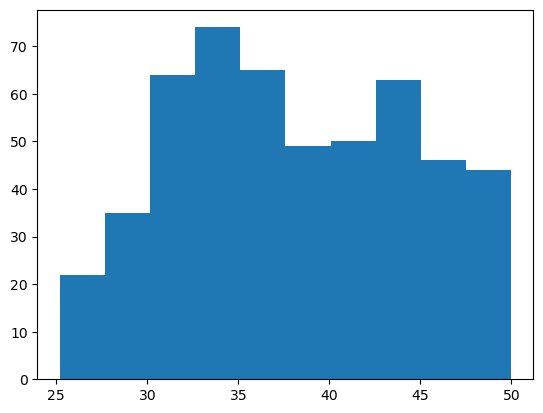

In [15]:
plt.hist(filter.errors())

In [ ]:
filter_abc_dtw = filter.copy()

noise = ObsVecNoise.additive_normal(std_dev=50.0)

for threshold in [45, 40, 38]:
    ess = filter_abc_dtw.abc_mvnk(metric='dtw', threshold=threshold, noise=noise)
    print("Filtering with threshold {}, effective sample size: {:.1f}".format(threshold, ess))

print("ABC Mean: {:.3f}".format(np.mean(filter_abc_dtw.errors())))
print("ABC Minimum: {:.3f}".format(np.min(filter_abc_dtw.errors())))

particles_abc_dtw = filter_abc_dtw.particles()

Filtering with threshold 45, effective sample size: 317.0
Filtering with threshold 40, effective sample size: 415.7
Filtering with threshold 38, effective sample size: 412.1
ABC Mean: 34.061
ABC Minimum: 24.736


In [ ]:
filter_abc_rmse = model.new_pbs_filter(obs, np.array([ref_data[::4]]).T, 512, 44)
filter_abc_rmse.initialize("nrmse", 1.0)

noise = ObsVecNoise.additive_normal(std_dev=50.0)

for threshold in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.25]:
    ess = filter_abc_rmse.abc_mvnk(metric='nrmse', threshold=threshold, noise=noise)
    print("Filtering with threshold {}, effective sample size: {:.1f}".format(threshold, ess))

print("ABC Mean: {:.3f}".format(np.mean(filter_abc_rmse.errors())))
print("ABC Minimum: {:.3f}".format(np.min(filter_abc_rmse.errors())))

particles_abc_rmse = filter_abc_rmse.particles()

Filtering with threshold 0.9, effective sample size: 409.7
Filtering with threshold 0.8, effective sample size: 422.0
Filtering with threshold 0.7, effective sample size: 407.9
Filtering with threshold 0.6, effective sample size: 411.5
Filtering with threshold 0.5, effective sample size: 416.9
Filtering with threshold 0.4, effective sample size: 424.0
Filtering with threshold 0.3, effective sample size: 426.7
Filtering with threshold 0.25, effective sample size: 421.3
ABC Mean: 0.190
ABC Minimum: 0.174


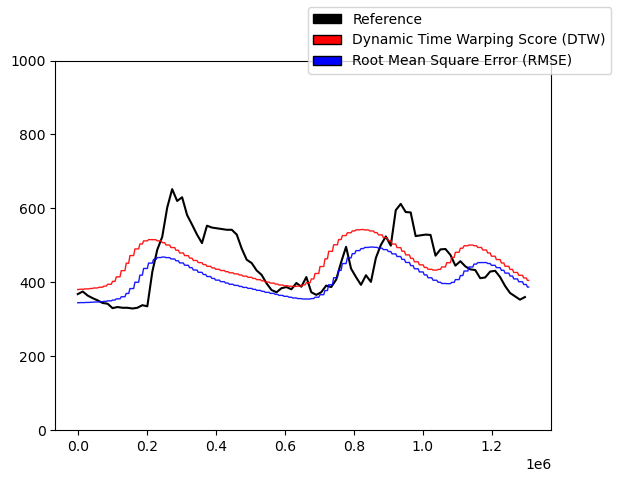

In [18]:
sim_obs = Obs(
    [3600 * i for i in range(len(ref_data))],
    np.array([[1.0, 0.0, 0.00] for _ in range(len(ref_data))]),
)

(result_dtw, errors_dtw) = filter_abc_dtw.simulate("dtw", sim_obs, np.array([ref_data]).T)
(result_rmse, errors_rmse) = filter_abc_rmse.simulate("nrmse", sim_obs, np.array([ref_data]).T)

cfig = plt.figure()
plt.plot(obs.timestamps(), ref_data[::4], "k")
plt.plot(sim_obs.timestamps(), result_dtw.get(np.argmin(particles_abc_dtw[1])), color="r", lw=1, alpha=0.9)
plt.plot(sim_obs.timestamps(), result_rmse.get(np.argmin(particles_abc_rmse[1])), color="b", lw=1, alpha=0.9)
plt.ylim([0, 1000])

cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Reference"),
    Patch(facecolor='r', edgecolor='k', label="Dynamic Time Warping Score (DTW)"),
    Patch(facecolor='b', edgecolor='k', label="Root Mean Square Error (RMSE)")
])
plt.show()

In [19]:
autorange = np.array([np.min(particles_init[0], axis=0), np.max(particles_init[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_init[0].T[autoflag].T, 
              weights=np.ones_like(particles_abc_rmse[1]) / 2048, color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_abc_dtw[0].T[autoflag].T, 
              weights=particles_abc_dtw[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_abc_rmse[0].T[autoflag].T, 
              weights=particles_abc_rmse[1], color='b',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Dynamic Time Warping Score (DTW)"),
    Patch(facecolor='b', edgecolor='k', label="Root Mean Square Error (RMSE)")
], loc='upper right')
plt.show()